In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
import pandas as pd

# Load the data from your Week 3 folder
df = pd.read_csv('cleaned_sales_data.csv')

# Check the first few rows and column types
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9800 non-null   int64  
 1   order_id       9800 non-null   object 
 2   order_date     9800 non-null   object 
 3   ship_date      9800 non-null   object 
 4   ship_mode      9800 non-null   object 
 5   customer_id    9800 non-null   object 
 6   customer_name  9800 non-null   object 
 7   segment        9800 non-null   object 
 8   country        9800 non-null   object 
 9   city           9800 non-null   object 
 10  state          9800 non-null   object 
 11  postal_code    9800 non-null   float64
 12  region         9800 non-null   object 
 13  product_id     9800 non-null   object 
 14  category       9800 non-null   object 
 15  sub-category   9800 non-null   object 
 16  product_name   9800 non-null   object 
 17  sales          9800 non-null   float64
dtypes: float

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [101]:
# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Create a 'Month-Year' column for easier plotting
df['Month_Year'] = df['order_date'].dt.to_period('M')

# Check the conversion
print(df['order_date'].dtype)
df.head()

datetime64[ns]


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,Month_Year
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017-11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017-11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017-06
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016-10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016-10


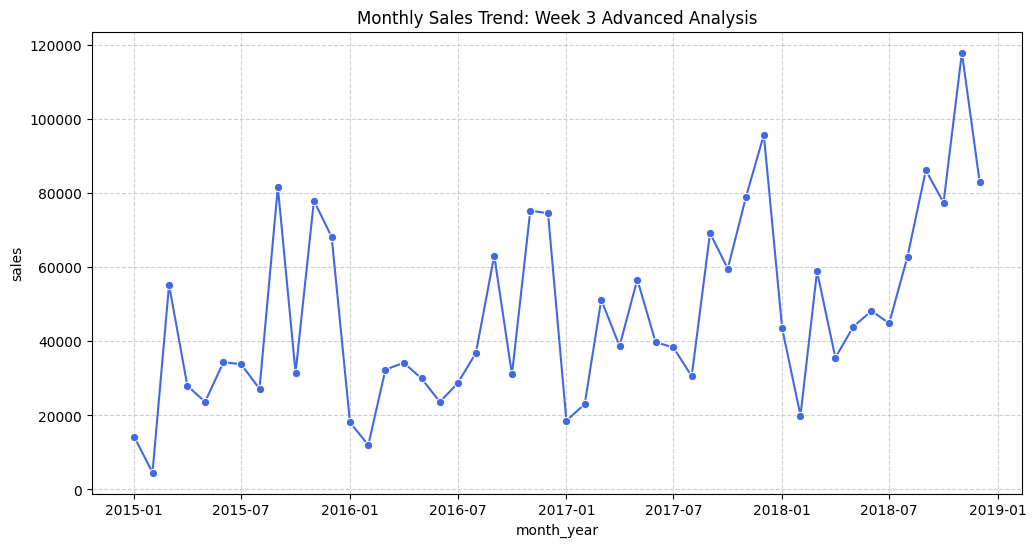

In [102]:
# 1. Create a month-year column for grouping
df['month_year'] = df['order_date'].dt.to_period('M')

# 2. Sum sales by month
monthly_sales = df.groupby('month_year')['sales'].sum().reset_index()

# 3. Convert month_year back to a format matplotlib can plot
monthly_sales['month_year'] = monthly_sales['month_year'].dt.to_timestamp()

# 4. Plot the results
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='month_year', y='sales', marker='o', color='royalblue')
plt.title('Monthly Sales Trend: Week 3 Advanced Analysis')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [103]:
# Create a Year-Month column for grouping
df['year_month'] = df['order_date'].dt.to_period('M')

# Group by month and sum the sales
monthly_trends = df.groupby('year_month')['sales'].sum().reset_index()

# Convert back to timestamp so the chart can read it correctly
monthly_trends['year_month'] = monthly_trends['year_month'].dt.to_timestamp()

print("Monthly Sales Data Prepared:")
print(monthly_trends.head())

Monthly Sales Data Prepared:
  year_month      sales
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303


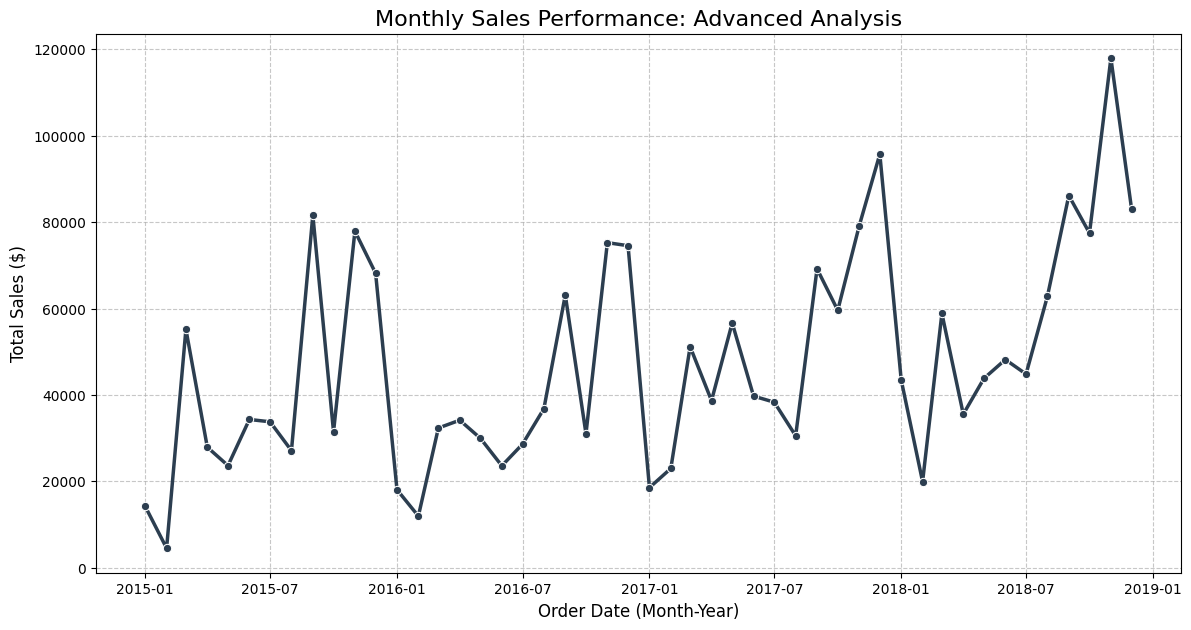

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_trends, x='year_month', y='sales', marker='o', linewidth=2.5, color='#2c3e50')

plt.title('Monthly Sales Performance: Advanced Analysis', fontsize=16)
plt.xlabel('Order Date (Month-Year)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

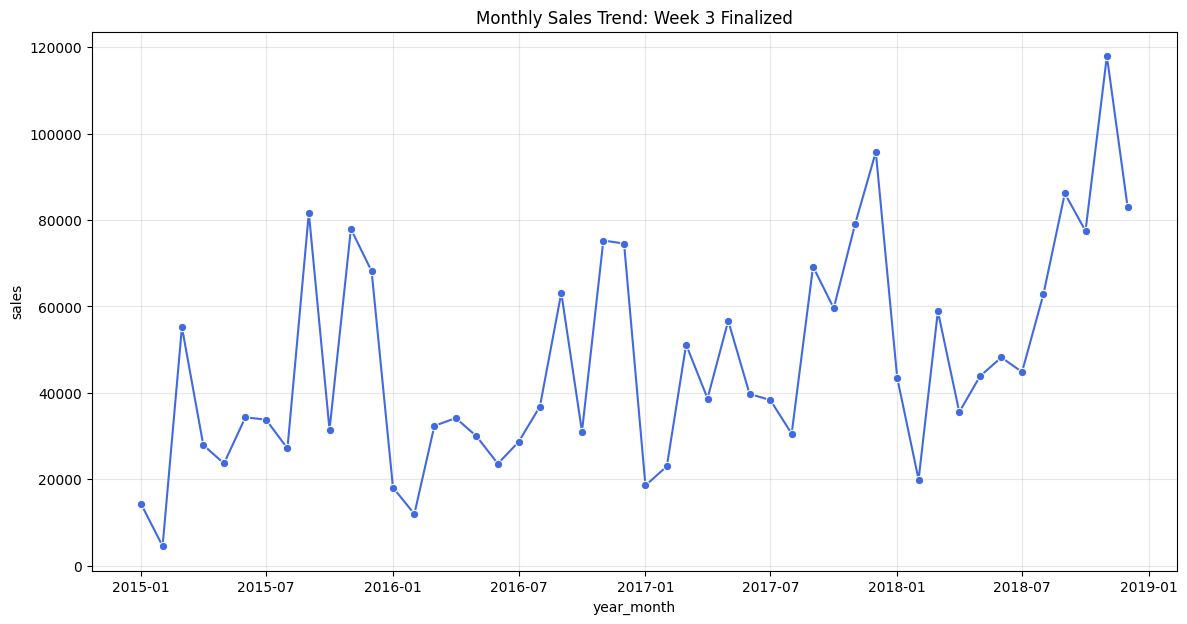

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data fresh
df = pd.read_csv('cleaned_sales_data.csv')

# 2. AUTO-FIX names: This turns 'Order Date' or 'ORDER_DATE' into 'order_date'
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 3. Use the new standardized name 'order_date'
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['year_month'] = df['order_date'].dt.to_period('M')

# 4. Group only Sales (using the lowercase 'sales')
m_sales = df.groupby('year_month')['sales'].sum().reset_index()
m_sales['year_month'] = m_sales['year_month'].dt.to_timestamp()

# 5. Generate the Chart
plt.figure(figsize=(14, 7))
sns.lineplot(data=m_sales, x='year_month', y='sales', color='royalblue', marker='o')
plt.title('Monthly Sales Trend: Week 3 Finalized')
plt.grid(True, alpha=0.3)
plt.show()